In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pyuda
client = pyuda.Client()

import sys
sys.path.insert(0, '/home/sthoma/bes/')
import myFuncs as mf

-------------------Loading module Divertor-------------------
-------------------Loading module Utilities-------------------


In [2]:
%matplotlib widget

In [3]:
def cart2cyl(arr):
    """arr should be an array of length three and contain the coordinates
    [x, y, z] and returns the cylidrical coordinates [phi, R, z] where
    0 <= phi < 360 degrees"""
    if arr.ndim == 1:
        phi = np.rad2deg(np.arctan(arr[1] / arr[0]))
        if phi > 0: #in either top right or bottom left quadrant
            if arr[0] < 0 and arr[1] < 0: #bottom left quadrant
                phi += 180.
        else: #in either top left or bottom right quadrant
            if arr[0] < 0: #top left quadrant
                phi += 180.
            else: #bottom right quadrant
                phi += 360.
        R = np.sqrt(arr[0]**2 + arr[1]**2)
        z = arr[2]
        new_arr = np.array([phi, R, z])
    else:
        new_arr = np.zeros_like(arr)
        new_arr[:,0] = np.rad2deg(np.arctan(arr[:,1] / arr[:,0]))
        new_arr[:,1] = np.sqrt(arr[:,0]**2 + arr[:,1]**2)
        new_arr[:,2] = arr[:,2]
        for i in range(0, arr.shape[0]):
            if new_arr[i,0] > 0:
                if arr[i,0] < 0 and arr[i,1] < 0:
                    new_arr[i,0] += 180.
            else:
                if arr[i,0] < 0:
                    new_arr[i,0] += 180.
                else:
                    new_arr[i,0] += 360.
    return new_arr

def magnitude_func(arr, axis=-1):
    """only works on cartesian coordinates"""
    return np.sqrt(np.sum(arr**2, axis=axis))

In [4]:
shotMag = 49091
timeMag = 0.5

In [5]:
### radius of vessel wall, SS beam port location, metres
radiusWall = 2.033
### radius of centre column, metres
radiusCC = 0.260841
### information for xspaceSS, the xrange the SS beam acts over
x0 = 0.543 # metres
x1 = 0.862 # metres
xn = 1001 # number points for xplot
xlen = int(((x1 - x0) * 1e3) + 2)

### find out the radii to add to the plot
rhoLim = mf.getRhoLimiter(shotMag, timeMag)
radiusLim = mf.rho2R(rhoLim, shotMag, timeMag)
radiusAxis = mf.getMagneticAxis(shotMag,
            [timeMag-2.5e-3,timeMag+2.5e-3])[0]
radiusSepOut, radiusSepIn = mf.getRadiusIO(shotMag, timeMag)

### find the x and y coordinates of the bits above
xplot = np.linspace(-radiusWall, radiusWall, xn)
yplot = np.sqrt(radiusWall**2 - xplot**2)
xCC = np.linspace(-radiusCC, radiusCC, xn)
yCC = np.sqrt(radiusCC**2 - xCC**2)
xSepOut = np.linspace(-radiusSepOut, radiusSepOut, xn)
ySepOut = np.sqrt(radiusSepOut**2 - xSepOut**2)
xLim = np.linspace(-radiusLim, radiusLim, xn)
yLim = np.sqrt(radiusLim**2 - xLim**2)
xSepIn = np.linspace(-radiusSepIn, radiusSepIn, xn)
ySepIn = np.sqrt(radiusSepIn**2 - xSepIn**2)
xAxis = np.linspace(-radiusAxis, radiusAxis, xn)
yAxis = np.sqrt(radiusAxis**2 - xAxis**2)

### load beam data
with open('/home/sthoma/bes/data/beam_geometry_data.pkl', 'rb') as handle:
    data =  pickle.load(handle)
### SS beam data
ss = data['ss_beam']
beamSS = ss['axis']
sourceSS = ss['src'] / 100.
### gradient of line describing SS
mSS = beamSS[1] / beamSS[0]
### intercept of line describing SS
CSS = sourceSS[1] - (sourceSS[0] *
      beamSS[1] / beamSS[0])
### y co-ordinates of SS beam
ySS = mSS * xplot + CSS

### SW beam data
sw = data['sw_beam']
beamSW = sw['axis']
sourceSW = sw['src'] / 100.
### gradient of line describing SW
mSW = beamSW[1] / beamSW[0]
### intercept of line describing SW
CSW = sourceSW[1] - (sourceSW[0] *
      beamSW[1] / beamSW[0])
### y co-ordinates of SW beam
ySW = mSW * xplot + CSW

### space SS beam acts over
xspaceSS = np.linspace(x0, x1, xlen)
yspaceSS = mSS * xspaceSS + CSS
xstep = np.diff(xspaceSS).mean()
### radius of the SS beam
RspaceSS = np.sqrt(xspaceSS**2 + yspaceSS**2)
### lower half of beam, before tangency point
boo = yspaceSS < 0.
Rbeam = np.sqrt(xspaceSS[boo]**2 + yspaceSS[boo]**2)
RspaceSW = np.sqrt(xplot**2 + ySW**2)

In [6]:
cMag = 'C3'
cWall = 'k'
cLim = 'C7'
colours = ['C0', 'C1', 'C2', 'C5', 'C6', 'C8', 'C9']
lineType = ['-', '--', ':']
Nc = len(colours)
xlim = [-2.2, 1.2]
ylim = [-2.2, 1.2]

In [7]:
def move(dR, angle, posn, yopp=False, dz=0.):
    dx = dR * np.cos(angle)
    dy = dR * np.sin(angle)
    if yopp:
        dy *= -1.
    newPosn = posn + np.array([dx, dy, dz])
    newCyl = cart2cyl(newPosn)
    return newPosn, newCyl

In [8]:
lensCart = np.array([-1.320, -1.108, 0.])
lensCyl = cart2cyl(lensCart)
sensorCart = np.array([-1.680,-1.476, 0.])
sensorCyl = cart2cyl(sensorCart)
HSVm = (lensCart[1] - sensorCart[1]) / (lensCart[0] - sensorCart[0])
HSVc = sensorCart[1] - (HSVm * sensorCart[0])
angleRad = np.arctan(HSVm)
angleDeg = np.rad2deg(angleRad)


dRbolt1 = -0.333 # The distance from sensor to back bolt
bolt1Cart, bolt1Cyl = move(dRbolt1, angleRad, sensorCart)
dRbolt2 = 0.34784 # The distance from back bolt to front bolt
bolt2Cart, bolt2Cyl = move(dRbolt2, angleRad, bolt1Cart)


xCam = xplot[(xplot >= bolt1Cart[0]) * (xplot <= 0.5)]
yCam = xCam * HSVm + HSVc


angleDegL = angleDeg + 5.0
angleRadL = np.deg2rad(angleDegL)
HSVmL = np.tan(angleRadL)
HSVcL = bolt1Cart[1] - (HSVmL * bolt1Cart[0])
yCamL = xCam * HSVmL + HSVcL
angleDegR = angleDeg - 5.3
angleRadR = np.deg2rad(angleDegR)
HSVmR = np.tan(angleRadR)
HSVcR = bolt1Cart[1] - (HSVmR * bolt1Cart[0])
yCamR = xCam * HSVmR + HSVcR

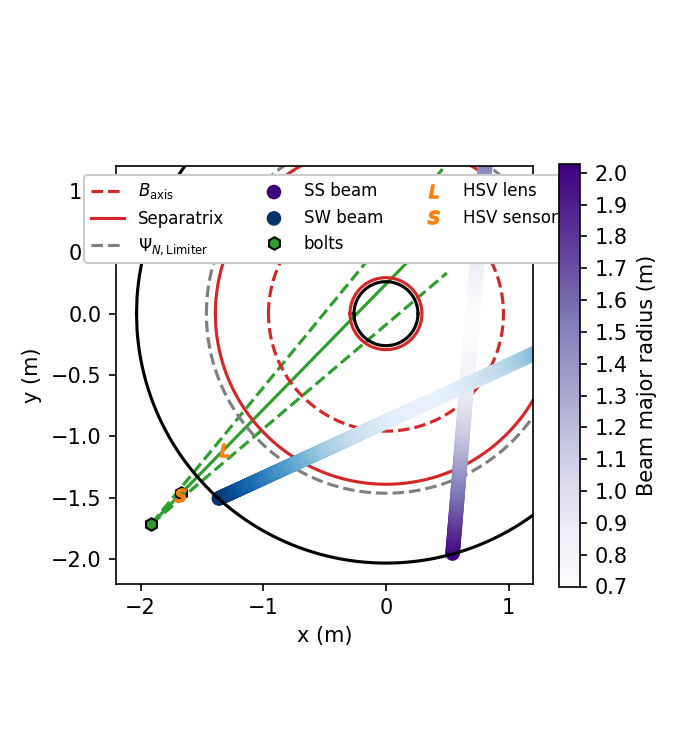

In [9]:
i=0
### create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(4.5,5), dpi=150)
### add magnetic and machine wall circles
ax.plot(np.append(xAxis, xAxis[::-1]), np.append(yAxis, -yAxis),
        '--', c=cMag, label='$B_\\mathrm{{axis}}$', zorder=2)
ax.plot(xplot, yplot, '-', c=cWall, zorder=5)
ax.plot(xplot, -yplot, '-', c=cWall, zorder=5)
ax.plot(xCC, yCC, '-', c=cWall, zorder=5)
ax.plot(xCC, -yCC, '-', c=cWall, zorder=5)
ax.plot(np.append(xSepOut, xSepOut[::-1]), np.append(ySepOut, -ySepOut),
        '-', c=cMag, label='Separatrix', zorder=2)
ax.plot(np.append(xSepIn, xSepIn[::-1]), np.append(ySepIn, -ySepIn),
        '-', c=cMag, zorder=2)
ax.plot(np.append(xLim, xLim[::-1]), np.append(yLim, -yLim),
        '--', c=cLim, label='$\\Psi_{N,\\mathrm{Limiter}}$', zorder=2)

### adding beams
sc=ax.scatter(xspaceSS, yspaceSS, c=RspaceSS, marker='o',
              vmin=0.7, vmax=RspaceSS.max(),
              cmap=plt.cm.Purples, label='SS beam', zorder=2)
fig.colorbar(sc, ax=ax, label='Beam major radius (m)', 
             ticks=np.arange(0.7, 2.09, 0.1), shrink=0.6)
booSW = np.sqrt(xplot**2 + ySW**2) <= radiusWall
# colour = colours[(i+1)%Nc]
# ax.plot(xplot[booSW], ySW[booSW], lineType[(i+1)//Nc],
#         color=colour, label='SW beam', zorder=2)
sc=ax.scatter(xplot[booSW], ySW[booSW], c=RspaceSW[booSW], marker='o',
              vmin=0.7, vmax=RspaceSS.max(),
              cmap=plt.cm.Blues, label='SW beam', zorder=2)

# ax.plot(lensCart[0], lensCart[1], marker='$L$', linestyle='None', c='C2', label='HSV lens')
ax.plot(xCam, yCam, '-', c='C2', zorder=1)
ax.plot(xCam, yCamL, '--', c='C2', zorder=1)
ax.plot(xCam, yCamR, '--', c='C2', zorder=1)
ax.plot(bolt1Cart[0], bolt1Cart[1], marker='h', linestyle='None', c='C2', mec='k', label='bolts')
ax.plot(bolt2Cart[0], bolt2Cart[1], marker='h', linestyle='None', c='C2', mec='k')
ax.plot(lensCart[0], lensCart[1], marker='$L$', linestyle='None', c='C1', label='HSV lens')
ax.plot(sensorCart[0], sensorCart[1], marker='$s$', linestyle='None', c='C1', label='HSV sensor')



### rest of plotting
ax.legend(fancybox=1, framealpha=1, loc='upper center', ncol=3, fontsize=8)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.tight_layout()

In [10]:
boltm = -1. / HSVm # perpendicular to optical axis
boltAngle = np.abs(np.arctan(boltm)) # angle of it
bolt1c = bolt1Cart[1] - (boltm * bolt1Cart[0]) # intercept for bolt1
bolt2c = bolt2Cart[1] - (boltm * bolt2Cart[0]) # intercept for bolt2

dRbolt = 32.36 * 1e-3
dxbolt = dRbolt * np.cos(boltAngle)
dybolt = dRbolt * np.sin(boltAngle)

bolt1ACart = bolt1Cart + np.array([dxbolt, -dybolt, 0.])
bolt2ACart = bolt2Cart - np.array([dxbolt, -dybolt, 0.])
bolt1BCart = bolt1Cart - np.array([dxbolt, -dybolt, 0.])
bolt2BCart = bolt2Cart + np.array([dxbolt, -dybolt, 0.])

# angleAdeg = angleDeg + np.mean([10.2, 9.73, 10.3, 10.5])
angleAdeg = angleDeg + 10.25
angleArad = np.deg2rad(angleAdeg)
mA = np.tan(angleArad)
cA = bolt1ACart[1] - (mA * bolt1ACart[0])
xCamA = xplot[(xplot >= bolt1ACart[0]) * (xplot <= 0.5)]
yCamA = xCamA * mA + cA
# angleBdeg = angleDeg - np.mean([11.0, 11.1,  9.7, 11.0])
angleBdeg = angleDeg - 10.25
angleBrad = np.deg2rad(angleBdeg)
mB = np.tan(angleBrad)
cB = bolt1BCart[1] - (mB * bolt1BCart[0])
xCamB = xplot[(xplot >= bolt1BCart[0]) * (xplot <= 0.5)]
yCamB = xCamB * mB + cB

In [11]:
portDiameter = 0.106 * 2.
portA = lensCart + np.array([0.5 * portDiameter * np.cos(boltAngle), -0.5 * portDiameter * np.sin(boltAngle), 0.])
portB = lensCart - np.array([0.5 * portDiameter * np.cos(boltAngle), -0.5 * portDiameter * np.sin(boltAngle), 0.])
portC = portA - np.array([np.cos(angleRad), np.sin(angleRad), 0.]) * 0.35
portD = portB - np.array([np.cos(angleRad), np.sin(angleRad), 0.]) * 0.35

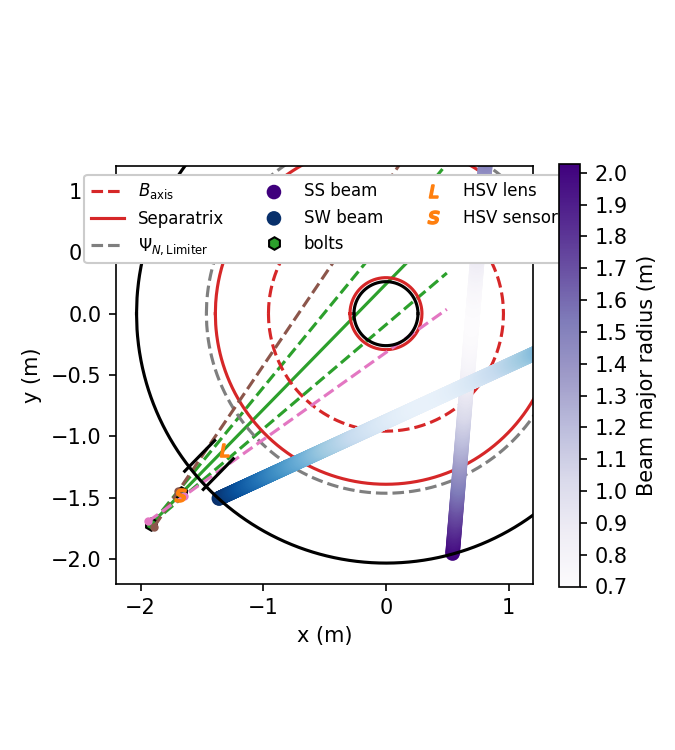

In [12]:
i=0
### create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(4.5,5), dpi=150)
### add magnetic and machine wall circles
ax.plot(np.append(xAxis, xAxis[::-1]), np.append(yAxis, -yAxis),
        '--', c=cMag, label='$B_\\mathrm{{axis}}$', zorder=2)
ax.plot(xplot, yplot, '-', c=cWall, zorder=5)
ax.plot(xplot, -yplot, '-', c=cWall, zorder=5)
ax.plot(xCC, yCC, '-', c=cWall, zorder=5)
ax.plot(xCC, -yCC, '-', c=cWall, zorder=5)
ax.plot(np.append(xSepOut, xSepOut[::-1]), np.append(ySepOut, -ySepOut),
        '-', c=cMag, label='Separatrix', zorder=2)
ax.plot(np.append(xSepIn, xSepIn[::-1]), np.append(ySepIn, -ySepIn),
        '-', c=cMag, zorder=2)
ax.plot(np.append(xLim, xLim[::-1]), np.append(yLim, -yLim),
        '--', c=cLim, label='$\\Psi_{N,\\mathrm{Limiter}}$', zorder=2)

### adding beams
sc=ax.scatter(xspaceSS, yspaceSS, c=RspaceSS, marker='o',
              vmin=0.7, vmax=RspaceSS.max(),
              cmap=plt.cm.Purples, label='SS beam', zorder=2)
fig.colorbar(sc, ax=ax, label='Beam major radius (m)', 
             ticks=np.arange(0.7, 2.09, 0.1), shrink=0.6)
booSW = np.sqrt(xplot**2 + ySW**2) <= radiusWall
# colour = colours[(i+1)%Nc]
# ax.plot(xplot[booSW], ySW[booSW], lineType[(i+1)//Nc],
#         color=colour, label='SW beam', zorder=2)
sc=ax.scatter(xplot[booSW], ySW[booSW], c=RspaceSW[booSW], marker='o',
              vmin=0.7, vmax=RspaceSS.max(),
              cmap=plt.cm.Blues, label='SW beam', zorder=2)

# ax.plot(lensCart[0], lensCart[1], marker='$L$', linestyle='None', c='C2', label='HSV lens')
ax.plot(xCam, yCam, '-', c='C2', zorder=1)
ax.plot(xCam, yCamL, '--', c='C2', zorder=1)
ax.plot(xCam, yCamR, '--', c='C2', zorder=1)
ax.plot(bolt1Cart[0], bolt1Cart[1], marker='h', linestyle='None', c='C2', mec='k', label='bolts')
ax.plot(bolt2Cart[0], bolt2Cart[1], marker='h', linestyle='None', c='C2', mec='k')
ax.plot(bolt1ACart[0], bolt1ACart[1], marker='.', linestyle='None', c='C5')
ax.plot(bolt2ACart[0], bolt2ACart[1], marker='.', linestyle='None', c='C5')
ax.plot(xCamA, yCamA, '--', c='C5')
ax.plot(bolt1BCart[0], bolt1BCart[1], marker='.', linestyle='None', c='C6')
ax.plot(bolt2BCart[0], bolt2BCart[1], marker='.', linestyle='None', c='C6')
ax.plot(xCamB, yCamB, '--', c='C6')

ax.plot(lensCart[0], lensCart[1], marker='$L$', linestyle='None', c='C1', label='HSV lens')
ax.plot(sensorCart[0], sensorCart[1], marker='$s$', linestyle='None', c='C1', label='HSV sensor')
ax.plot([portA[0], portC[0]], [portA[1], portC[1]], '-k')
ax.plot([portB[0], portD[0]], [portB[1], portD[1]], '-k')




### rest of plotting
ax.legend(fancybox=1, framealpha=1, loc='upper center', ncol=3, fontsize=8)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.tight_layout()

In [13]:
midbracketCart = np.array([-1.506, -1.294, 0.])
midbracketCyl = cart2cyl(midbracketCart)
dRbracket = ((125. / 2.) + 10.) * 1e-3
bracket1Cart, bracket1Cyl = move(dRbracket, angleRad, midbracketCart)
bracket1Cart, bracket1Cyl = move(0.0028904158425833754, boltAngle, bracket1Cart, yopp=True)
bracket1CartA, bracket1CylA = move(0.01, boltAngle, bracket1Cart, yopp=True)
bracket1CartB, bracket1CylB = move(-0.01, boltAngle, bracket1Cart, yopp=True)
bracket2Cart, bracket2Cyl = move(-dRbracket, angleRad, midbracketCart)
bracket2Cart, bracket2Cyl = move(0.002890415842583453, boltAngle, bracket2Cart, yopp=True)
bracket2CartA, bracket2CylA = move(0.01, boltAngle, bracket2Cart, yopp=True)
bracket2CartB, bracket2CylB = move(-0.01, boltAngle, bracket2Cart, yopp=True)

In [14]:
hm08Cart = np.array([-1.5238,-1.5238, 0.])
hm08Cyl = cart2cyl(hm08Cart)
hm08Angle = np.deg2rad(270. - hm08Cyl[0])
hm08Radius = 0.3
hm08CartA = hm08Cart + (hm08Radius * np.array([-np.cos(hm08Angle),np.sin(hm08Angle), 0.]))
hm08CartB = hm08Cart - (hm08Radius * np.array([-np.cos(hm08Angle),np.sin(hm08Angle), 0.]))

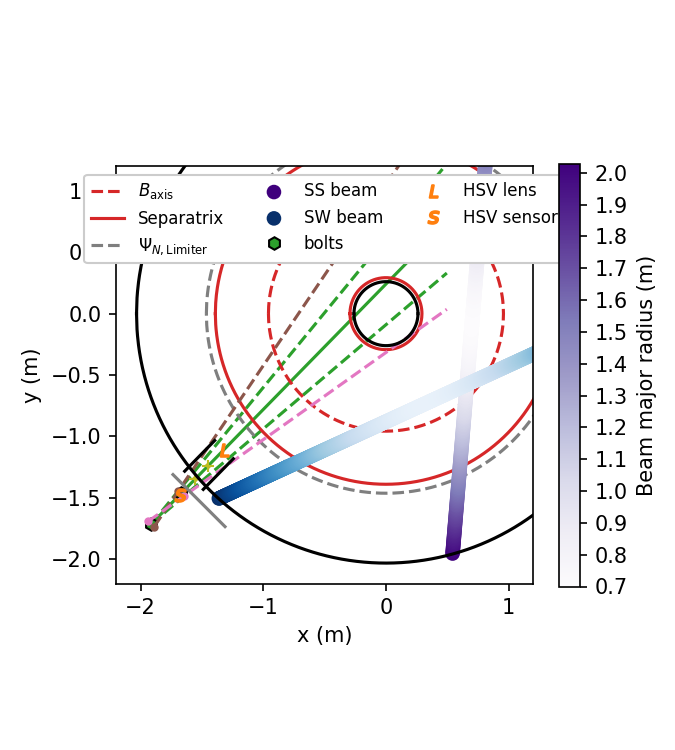

In [15]:
i=0
### create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(4.5,5), dpi=150)
### add magnetic and machine wall circles
ax.plot(np.append(xAxis, xAxis[::-1]), np.append(yAxis, -yAxis),
        '--', c=cMag, label='$B_\\mathrm{{axis}}$', zorder=2)
ax.plot(xplot, yplot, '-', c=cWall, zorder=5)
ax.plot(xplot, -yplot, '-', c=cWall, zorder=5)
ax.plot(xCC, yCC, '-', c=cWall, zorder=5)
ax.plot(xCC, -yCC, '-', c=cWall, zorder=5)
ax.plot(np.append(xSepOut, xSepOut[::-1]), np.append(ySepOut, -ySepOut),
        '-', c=cMag, label='Separatrix', zorder=2)
ax.plot(np.append(xSepIn, xSepIn[::-1]), np.append(ySepIn, -ySepIn),
        '-', c=cMag, zorder=2)
ax.plot(np.append(xLim, xLim[::-1]), np.append(yLim, -yLim),
        '--', c=cLim, label='$\\Psi_{N,\\mathrm{Limiter}}$', zorder=2)

### adding beams
sc=ax.scatter(xspaceSS, yspaceSS, c=RspaceSS, marker='o',
              vmin=0.7, vmax=RspaceSS.max(),
              cmap=plt.cm.Purples, label='SS beam', zorder=2)
fig.colorbar(sc, ax=ax, label='Beam major radius (m)', 
             ticks=np.arange(0.7, 2.09, 0.1), shrink=0.6)
booSW = np.sqrt(xplot**2 + ySW**2) <= radiusWall
# colour = colours[(i+1)%Nc]
# ax.plot(xplot[booSW], ySW[booSW], lineType[(i+1)//Nc],
#         color=colour, label='SW beam', zorder=2)
sc=ax.scatter(xplot[booSW], ySW[booSW], c=RspaceSW[booSW], marker='o',
              vmin=0.7, vmax=RspaceSS.max(),
              cmap=plt.cm.Blues, label='SW beam', zorder=2)

# ax.plot(lensCart[0], lensCart[1], marker='$L$', linestyle='None', c='C2', label='HSV lens')
ax.plot(xCam, yCam, '-', c='C2', zorder=1)
ax.plot(xCam, yCamL, '--', c='C2', zorder=1)
ax.plot(xCam, yCamR, '--', c='C2', zorder=1)
ax.plot(bolt1Cart[0], bolt1Cart[1], marker='h', linestyle='None', c='C2', mec='k', label='bolts')
ax.plot(bolt2Cart[0], bolt2Cart[1], marker='h', linestyle='None', c='C2', mec='k')
ax.plot(bolt1ACart[0], bolt1ACart[1], marker='.', linestyle='None', c='C5')
ax.plot(bolt2ACart[0], bolt2ACart[1], marker='.', linestyle='None', c='C5')
ax.plot(xCamA, yCamA, '--', c='C5')
ax.plot(bolt1BCart[0], bolt1BCart[1], marker='.', linestyle='None', c='C6')
ax.plot(bolt2BCart[0], bolt2BCart[1], marker='.', linestyle='None', c='C6')
ax.plot(xCamB, yCamB, '--', c='C6')

ax.plot(lensCart[0], lensCart[1], marker='$L$', linestyle='None', c='C1', label='HSV lens')
ax.plot(sensorCart[0], sensorCart[1], marker='$s$', linestyle='None', c='C1', label='HSV sensor')
ax.plot([portA[0], portC[0]], [portA[1], portC[1]], '-k')
ax.plot([portB[0], portD[0]], [portB[1], portD[1]], '-k')


ax.plot(bracket1Cart[0], bracket1Cart[1], marker='+', c='C8')
ax.plot(bracket2Cart[0], bracket2Cart[1], marker='+', c='C8')
ax.plot([bracket1CartA[0],bracket1CartB[0]], [bracket1CartA[1],bracket1CartB[1]], c='C8')
ax.plot([bracket2CartA[0],bracket2CartB[0]], [bracket2CartA[1],bracket2CartB[1]], c='C8')

ax.plot([hm08CartA[0],hm08CartB[0]], [hm08CartA[1],hm08CartB[1]], '-', c='gray')

### rest of plotting
ax.legend(fancybox=1, framealpha=1, loc='upper center', ncol=3, fontsize=8)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.tight_layout()

In [16]:
matrix = np.array([[np.cos(-angleRad), -np.sin(-angleRad)],[np.sin(-angleRad), np.cos(-angleRad)]])
newOrigin = bolt1Cart

newbolt1 = np.matmul(matrix, (bolt1Cart - newOrigin)[:-1])
newbolt2 = np.matmul(matrix, (bolt2Cart - newOrigin)[:-1])
newbolt1A = np.matmul(matrix, (bolt1ACart - newOrigin)[:-1])
newbolt1B = np.matmul(matrix, (bolt1BCart - newOrigin)[:-1])
newbolt2A = np.matmul(matrix, (bolt2ACart - newOrigin)[:-1])
newbolt2B = np.matmul(matrix, (bolt2BCart - newOrigin)[:-1])
newBracket1 = np.matmul(matrix, (bracket1Cart - newOrigin)[:-1])
newBracket2 = np.matmul(matrix, (bracket2Cart - newOrigin)[:-1])
newBracket1A = np.matmul(matrix, (bracket1CartA - newOrigin)[:-1])
newBracket2A = np.matmul(matrix, (bracket2CartA - newOrigin)[:-1])
newBracket1B = np.matmul(matrix, (bracket1CartB - newOrigin)[:-1])
newBracket2B = np.matmul(matrix, (bracket2CartB - newOrigin)[:-1])

newLens = np.matmul(matrix, (lensCart - newOrigin)[:-1])
newSensor = np.matmul(matrix, (sensorCart - newOrigin)[:-1])
newportA = np.matmul(matrix, (portA - newOrigin)[:-1])
newportB = np.matmul(matrix, (portB - newOrigin)[:-1])
newportC = np.matmul(matrix, (portC - newOrigin)[:-1])
newportD = np.matmul(matrix, (portD - newOrigin)[:-1])

allCam = np.array([xCam, yCam, np.zeros_like(xCam)]).T
newCam = np.matmul(matrix, (allCam - newOrigin).T[:-1])
allCamA = np.array([xCamA, yCamA, np.zeros_like(xCamA)]).T
newCamA = np.matmul(matrix, (allCamA - newOrigin).T[:-1])
allCamB = np.array([xCamB, yCamB, np.zeros_like(xCamB)]).T
newCamB = np.matmul(matrix, (allCamB - newOrigin).T[:-1])
allCamL = np.array([xCam, yCamL, np.zeros_like(xCam)]).T
newCamL = np.matmul(matrix, (allCamL - newOrigin).T[:-1])
allCamR = np.array([xCam, yCamR, np.zeros_like(xCam)]).T
newCamR = np.matmul(matrix, (allCamR - newOrigin).T[:-1])

allPlot = np.array([xplot, yplot, np.zeros_like(xplot)]).T
newPlot = np.matmul(matrix, (allPlot - newOrigin).T[:-1])
allPlot2 = np.array([xplot, -yplot, np.zeros_like(xplot)]).T
newPlot2 = np.matmul(matrix, (allPlot2 - newOrigin).T[:-1])

allCC = np.array([xCC, yCC, np.zeros_like(xCC)]).T
allCC2 = np.array([xCC, -yCC, np.zeros_like(xCC)]).T
newCC = np.matmul(matrix, (allCC - newOrigin).T[:-1])
newCC2 = np.matmul(matrix, (allCC2 - newOrigin).T[:-1])

In [17]:
newhm08A = np.matmul(matrix, (hm08CartA - newOrigin)[:-1])
newhm08B = np.matmul(matrix, (hm08CartB - newOrigin)[:-1])

In [18]:
allAxis = np.array([np.append(xAxis, xAxis[::-1]), np.append(yAxis, -yAxis), 
                      np.zeros_like(np.append(xAxis, xAxis[::-1]))]).T
allSepOut = np.array([np.append(xSepOut, xSepOut[::-1]), np.append(ySepOut, -ySepOut), 
                      np.zeros_like(np.append(xSepOut, xSepOut[::-1]))]).T
allSepIn = np.array([np.append(xSepIn, xSepIn[::-1]), np.append(ySepIn, -ySepIn), 
                      np.zeros_like(np.append(xSepIn, xSepIn[::-1]))]).T
allLim = np.array([np.append(xLim, xLim[::-1]), np.append(yLim, -yLim), 
                      np.zeros_like(np.append(xLim, xLim[::-1]))]).T
newAxis = np.matmul(matrix, (allAxis - newOrigin).T[:-1])
newSepOut = np.matmul(matrix, (allSepOut - newOrigin).T[:-1])
newSepIn = np.matmul(matrix, (allSepIn - newOrigin).T[:-1])
newLim = np.matmul(matrix, (allLim - newOrigin).T[:-1])

In [19]:
lensRadius = 31.75 * 1e-3
lensRadius1 = 22.5 * 1e-3
newCamFill0 = newCam[1] + lensRadius
newCamFill1 = newCam[1] - lensRadius
newCamFill2 = newCam[1] + lensRadius1
newCamFill3 = newCam[1] - lensRadius1
newCamFill0L = newCamL[1] + (lensRadius / np.cos(angleRadL))
newCamFill1L = newCamL[1] - (lensRadius / np.cos(angleRadL))
newCamFill2L = newCamL[1] + (lensRadius1 / np.cos(angleRadL))
newCamFill3L = newCamL[1] - (lensRadius1 / np.cos(angleRadL))
newCamFill0R = newCamR[1] + (lensRadius / np.cos(angleRadR))
newCamFill1R = newCamR[1] - (lensRadius / np.cos(angleRadR))
newCamFill2R = newCamR[1] + (lensRadius1 / np.cos(angleRadR))
newCamFill3R = newCamR[1] - (lensRadius1 / np.cos(angleRadR))

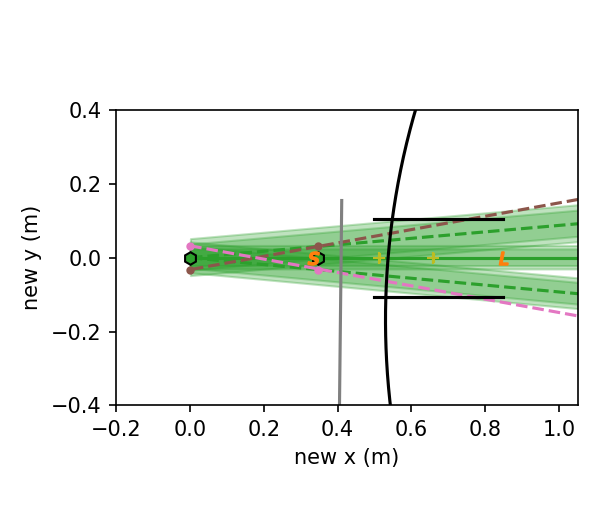

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(4,3.5), dpi=150)
ax.plot(newPlot[0], newPlot[1], '-', c=cWall, zorder=5)
ax.plot(newPlot2[0], newPlot2[1], '-', c=cWall, zorder=5)
ax.plot(newCC[0], newCC[1], '-', c=cWall, zorder=5)
ax.plot(newCC2[0], newCC2[1], '-', c=cWall, zorder=5)

ax.plot(newAxis[0], newAxis[1], '--', c=cMag, label='$B_\\mathrm{{axis}}$', zorder=2)
ax.plot(newSepOut[0], newSepOut[1], '-', c=cMag, label='Separatrix', zorder=2)
ax.plot(newSepIn[0], newSepIn[1], '-', c=cMag, zorder=2)
ax.plot(newLim[0], newLim[1], '--', c=cLim, label='$\\Psi_{N,\\mathrm{Limiter}}$', zorder=2)

ax.plot(newCam[0], newCam[1], '-', c='C2', zorder=1)
ax.fill_between(newCam[0], newCamFill0, newCamFill1, color='C2', alpha=0.3)
ax.fill_between(newCam[0], newCamFill2, newCamFill3, color='C2', alpha=0.3)
ax.plot(newCamL[0], newCamL[1], '--', c='C2', zorder=1)
ax.plot(newCamR[0], newCamR[1], '--', c='C2', zorder=1)
ax.fill_between(newCamL[0], newCamFill0L, newCamFill1L, color='C2', alpha=0.3)
ax.fill_between(newCamL[0], newCamFill2L, newCamFill3L, color='C2', alpha=0.3)
ax.fill_between(newCamR[0], newCamFill0R, newCamFill1R, color='C2', alpha=0.3)
ax.fill_between(newCamR[0], newCamFill2R, newCamFill3R, color='C2', alpha=0.3)
ax.plot(newbolt1[0], newbolt1[1], marker='h', linestyle='None', c='C2', mec='k', label='bolts')
ax.plot(newbolt2[0], newbolt2[1], marker='h', linestyle='None', c='C2', mec='k')
ax.plot(newbolt1A[0], newbolt1A[1], marker='.', linestyle='None', c='C5')
ax.plot(newbolt2A[0], newbolt2A[1], marker='.', linestyle='None', c='C5')
ax.plot(newCamA[0], newCamA[1], '--', c='C5')
ax.plot(newbolt1B[0], newbolt1B[1], marker='.', linestyle='None', c='C6')
ax.plot(newbolt2B[0], newbolt2B[1], marker='.', linestyle='None', c='C6')
ax.plot(newCamB[0], newCamB[1], '--', c='C6')

ax.plot(newLens[0], newLens[1], marker='$L$', linestyle='None', c='C1', label='HSV lens')
ax.plot(newSensor[0], newSensor[1], marker='$s$', linestyle='None', c='C1', label='HSV sensor')
ax.plot([newportA[0], newportC[0]], [newportA[1], newportC[1]], '-k')
ax.plot([newportB[0], newportD[0]], [newportB[1], newportD[1]], '-k')


ax.plot(newBracket1[0], newBracket1[1], marker='+', c='C8')
ax.plot(newBracket2[0], newBracket2[1], marker='+', c='C8')
ax.plot([newBracket1A[0],newBracket1B[0]], [newBracket1A[1],newBracket1B[1]], c='C8')
ax.plot([newBracket2A[0],newBracket2B[0]], [newBracket2A[1],newBracket2B[1]], c='C8')

ax.plot([newhm08A[0],newhm08B[0]], [newhm08A[1],newhm08B[1]], '-', c='gray')

ax.set_xlim([-0.2, 1.05])
ax.set_ylim([-0.4,0.4])
ax.set_xlabel('new x (m)')
ax.set_ylabel('new y (m)')
ax.set_aspect('equal')

plt.tight_layout()

In [21]:
bracketm1 = (newBracket1B[1] - newBracket2A[1]) / (newBracket1B[0] - newBracket2A[0])
bracket1c = newBracket1B[1] - (bracketm1 * newBracket1B[0])
ybracket1 = newCam[0] * bracketm1 + bracket1c
bracketAngle1 = np.arctan(bracketm1)

bracketm2 = (newBracket2B[1] - newBracket1A[1]) / (newBracket2B[0] - newBracket1A[0])
bracket2c = newBracket2B[1] - (bracketm2 * newBracket2B[0])
ybracket2 = newCam[0] * bracketm2 + bracket2c
bracketAngle2 = np.arctan(bracketm2)

ybracketFill0L = ybracket1 + (lensRadius / np.cos(angleRadL))
ybracketFill1L = ybracket1 - (lensRadius / np.cos(angleRadL))
ybracketFill2L = ybracket1 + (lensRadius1 / np.cos(angleRadL))
ybracketFill3L = ybracket1 - (lensRadius1 / np.cos(angleRadL))
newCamFill0R = ybracket1 + (lensRadius / np.cos(angleRadR))
newCamFill1R = ybracket1 - (lensRadius / np.cos(angleRadR))
newCamFill2R = ybracket1 + (lensRadius1 / np.cos(angleRadR))
newCamFill3R = ybracket1 - (lensRadius1 / np.cos(angleRadR))

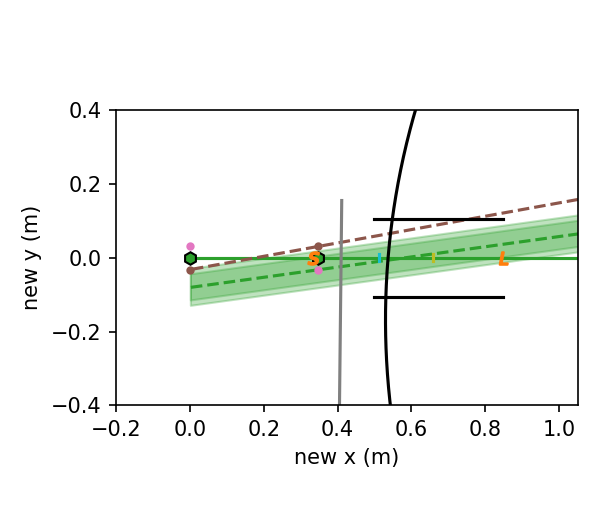

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(4,3.5), dpi=150)
ax.plot(newPlot[0], newPlot[1], '-', c=cWall, zorder=5)
ax.plot(newPlot2[0], newPlot2[1], '-', c=cWall, zorder=5)
ax.plot(newCC[0], newCC[1], '-', c=cWall, zorder=5)
ax.plot(newCC2[0], newCC2[1], '-', c=cWall, zorder=5)

ax.plot(newAxis[0], newAxis[1], '--', c=cMag, label='$B_\\mathrm{{axis}}$', zorder=2)
ax.plot(newSepOut[0], newSepOut[1], '-', c=cMag, label='Separatrix', zorder=2)
ax.plot(newSepIn[0], newSepIn[1], '-', c=cMag, zorder=2)
ax.plot(newLim[0], newLim[1], '--', c=cLim, label='$\\Psi_{N,\\mathrm{Limiter}}$', zorder=2)

ax.plot(newCam[0], newCam[1], '-', c='C2', zorder=1)

ax.plot(newCam[0], ybracket1, '--', c='C2', zorder=1)
# ax.plot(newCam[0], ybracket2, '--', c='C2', zorder=1)
ax.fill_between(newCam[0], ybracketFill0L, ybracketFill1L, color='C2', alpha=0.3)
ax.fill_between(newCam[0], ybracketFill2L, ybracketFill3L, color='C2', alpha=0.3)

ax.plot(newbolt1[0], newbolt1[1], marker='h', linestyle='None', c='C2', mec='k', label='bolts')
ax.plot(newbolt2[0], newbolt2[1], marker='h', linestyle='None', c='C2', mec='k')
ax.plot(newbolt1A[0], newbolt1A[1], marker='.', linestyle='None', c='C5')
ax.plot(newbolt2A[0], newbolt2A[1], marker='.', linestyle='None', c='C5')
ax.plot(newCamA[0], newCamA[1], '--', c='C5')
ax.plot(newbolt1B[0], newbolt1B[1], marker='.', linestyle='None', c='C6')
ax.plot(newbolt2B[0], newbolt2B[1], marker='.', linestyle='None', c='C6')
# ax.plot(newCamB[0], newCamB[1], '--', c='C6')

ax.plot(newLens[0], newLens[1], marker='$L$', linestyle='None', c='C1', label='HSV lens')
ax.plot(newSensor[0], newSensor[1], marker='$s$', linestyle='None', c='C1', label='HSV sensor')
ax.plot([newportA[0], newportC[0]], [newportA[1], newportC[1]], '-k')
ax.plot([newportB[0], newportD[0]], [newportB[1], newportD[1]], '-k')


# ax.plot(newBracket1[0], newBracket1[1], marker='+', c='C8')
# ax.plot(newBracket2[0], newBracket2[1], marker='+', c='C8')
ax.plot([newBracket1A[0],newBracket1B[0]], [newBracket1A[1],newBracket1B[1]], c='C8')
ax.plot([newBracket2A[0],newBracket2B[0]], [newBracket2A[1],newBracket2B[1]], c='C9')

ax.plot([newhm08A[0],newhm08B[0]], [newhm08A[1],newhm08B[1]], '-', c='gray')

ax.set_xlim([-0.2, 1.05])
ax.set_ylim([-0.4,0.4])
ax.set_xlabel('new x (m)')
ax.set_ylabel('new y (m)')
ax.set_aspect('equal')

plt.tight_layout()

In [23]:
newBracket1A

array([ 0.65727698, -0.01      ])

In [24]:
newBracket1B

array([0.65727698, 0.01      ])

In [25]:
newBracket2A

array([ 0.51227698, -0.01      ])

In [26]:
newBracket2B

array([0.51227698, 0.01      ])